In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar">
    <div class="usecase-title">Urban Flood Management and Emergency Response 2023</div>
</div>

<div class="usecase-details"><b>Authored by: </b>Sahan Chamod and Tharaka Sri</div>
<div class="usecase-details"><b>Date Created: </b>Trimester 1, 2025</div>
<div class="usecase-details"><b>Time to Complete:</b> 90 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, Pandas, basic geospatial concepts</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">As an urban planner working with the City of Melbourne, I want to know which parts of the city are most likely to flood during heavy rainfall, based on the actual condition and capacity of the stormwater network, so that I can prioritise infrastructure upgrades and help emergency response teams plan ahead of a storm rather than react after one.</div>

<div class="usecase-body">This use case aims to answer the following questions:</div>

<div class="usecase-list">

- Which parts of the city have the weakest stormwater drainage, based on pipe capacity, condition and coverage?
- Where should infrastructure upgrades and emergency response planning be prioritised first?

</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this use case will teach you</b></div>

<div class="usecase-body">By the end of this use case you will be able to:</div>

<div class="usecase-list">

- Retrieve and clean multiple related infrastructure datasets from the City of Melbourne Open Data API
- Combine several independent signals — drainage capacity, infrastructure condition and network density — into a single, defensible risk score
- Apply geospatial grid binning to compare infrastructure across the city on a common spatial unit
- Build static and interactive visualisations, including a flood risk heatmap
- Critically assess a dataset before using it, including recognising when a dataset is not fit for purpose

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">As urban areas face increasing pressure from climate change and rapid development, managing flood risk has become a genuine public safety and economic concern. Ageing or undersized stormwater infrastructure struggles to cope with heavy rainfall, and identifying exactly where that infrastructure is weakest is normally a slow, manual process for council engineers.</div>

<div class="usecase-body">This use case builds a theoretical flood risk score for different parts of Melbourne by combining three independent signals drawn from the City of Melbourne's stormwater asset data: how much water the drainage pipes in an area can physically carry, what condition that infrastructure is recorded as being in, and how densely served an area is by stormwater pits and pipes in the first place. None of these signals is a direct measurement of flooding, so the result is best read as a prioritisation tool for further investigation, not a flood forecast.</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">Two datasets from the City of Melbourne Open Data platform are used, both retrieved through the v2.1 export API.</div>

<div class="usecase-datasets">

- <a href="https://data.melbourne.vic.gov.au/explore/dataset/stormwater-pits/information/">Stormwater Pits</a> — the location, type and construction material of every stormwater pit in the city.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/drainpipes/information/">Drainpipes</a> — the location, capacity (diameter) and recorded condition of the city's drainage pipe network.

</div>

<div id="contents" class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

<ol>
<li><a href="#section-1">Set up the Python environment</a></li>
<li><a href="#section-2">Retrieve the stormwater and drainage data</a></li>
<li><a href="#section-3">Preparing the stormwater pit data</a>
<div style="margin-left:24px;">3.1. <a href="#subsection-3-1">Check data quality</a></div>
<div style="margin-left:24px;">3.2. <a href="#subsection-3-2">Clean the data</a></div>
<div style="margin-left:24px;">3.3. <a href="#subsection-3-3">Geospatial distribution of stormwater pits</a></div>
</li>
<li><a href="#section-4">Preparing the drainpipe data</a>
<div style="margin-left:24px;">4.1. <a href="#subsection-4-1">Check data quality</a></div>
<div style="margin-left:24px;">4.2. <a href="#subsection-4-2">Clean the data</a></div>
<div style="margin-left:24px;">4.3. <a href="#subsection-4-3">Geospatial distribution of drainpipes</a></div>
</li>
<li><a href="#section-5">Assessing drainage capacity and condition</a>
<div style="margin-left:24px;">5.1. <a href="#subsection-5-1">Distribution of pipe capacity</a></div>
<div style="margin-left:24px;">5.2. <a href="#subsection-5-2">Distribution of infrastructure condition</a></div>
<div style="margin-left:24px;">5.3. <a href="#subsection-5-3">Assigning capacity and condition risk bands</a></div>
</li>
<li><a href="#section-6">Assessing drainage network density</a>
<div style="margin-left:24px;">6.1. <a href="#subsection-6-1">Binning infrastructure into location grids</a></div>
<div style="margin-left:24px;">6.2. <a href="#subsection-6-2">Calculating a density risk band</a></div>
</li>
<li><a href="#section-7">Calculating the flood risk score</a>
<div style="margin-left:24px;">7.1. <a href="#subsection-7-1">Combine the risk signals</a></div>
<div style="margin-left:24px;">7.2. <a href="#subsection-7-2">Distribution of the flood risk score</a></div>
</li>
<li><a href="#section-8">Mapping high-risk flood zones</a>
<div style="margin-left:24px;">8.1. <a href="#subsection-8-1">Heatmap of flood risk across the city</a></div>
<div style="margin-left:24px;">8.2. <a href="#subsection-8-2">Identifying the highest-risk locations</a></div>
</li>
</ol>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Set up the Python environment</b></div>

<div class="usecase-body">Import the libraries used throughout this use case, covering data retrieval, data wrangling, and both static and interactive mapping.</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import folium
from io import StringIO
from functools import reduce
from folium.plugins import HeatMap

<div id="section-2" class="usecase-section-heading"><b>2. Retrieve the stormwater and drainage data</b></div>

<div class="usecase-body">Both datasets are retrieved from the City of Melbourne Open Data v2.1 export API as CSV. Neither dataset requires an API key, since this is a public export endpoint that does not require authentication.</div>

In [3]:
def collect_data(dataset_id):
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    url = f'{base_url}{dataset_id}/exports/csv'
    params = {
        'select': '*',
        'limit': -1,  # all records
        'lang': 'en',
        'timezone': 'UTC',
    }

    response = requests.get(url, params = params)
    if response.status_code == 200:
        url_content = response.content.decode('utf-8')
        return pd.read_csv(StringIO(url_content), delimiter = ';')
    else:
        print(f'Request failed with status code {response.status_code}')
        return None

stormwater_pits = collect_data('stormwater-pits')
drainpipes = collect_data('drainpipes')

print(f"Stormwater pits: {stormwater_pits.shape}")
print(f"Drainpipes: {drainpipes.shape}")

Stormwater pits: (21113, 13)
Drainpipes: (17242, 17)


<div id="section-3" class="usecase-section-heading"><b>3. Preparing the stormwater pit data</b></div>

<div class="usecase-body">Stormwater pits are the entry points into the drainage network, so their location and coverage across the city is the first signal used later in the flood risk score.</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1. Check data quality</b></div>

<div class="usecase-body">This check is run before any cleaning so that missing data is understood upfront rather than discovered partway through the analysis, particularly for the columns this use case actually relies on later.</div>

In [4]:
print(f'Shape of the stormwater pits data:\t{stormwater_pits.shape}')
stormwater_pits.head(5)

Shape of the stormwater pits data:	(21113, 13)


,asset_number,asset_description,construction_material_lupvalue,grate_length,grate_material_lupvalue,grate_width,model_descr_lupvalue,model_no_lupvalue,object_type_lupvalue,overflow_kerb_lupvalue,lat,lon,location
0,1147906,SWD Pit - Grated Side Entry,In Situ Concrete,930.0,Mild Steel,600.0,SWD Pit - Grated Side Entry Pit - Unclassified,300402-000,Grated Side Entry,NaN,-37.797887,144.967528,"-37.79788734091925, 144.9675280332414"
1,1579648,SWD Pit - Grated OFK,In Situ Concrete,930.0,Mild Steel,600.0,SWD Pit - Grated Overflow Kerb Pit - Exposed A...,300405-005,Grated OFK,Concrete,-37.793397,144.970860,"-37.79339663977309, 144.97086016916336"
2,1151908,SWD Pit - Not Known,Precast Concrete,0.0,Not Known,0.0,SWD Pit - Not Known,300418-000,Not Known,Not Known,-37.821908,144.971561,"-37.821907649833314, 144.97156085173935"
3,1759418,SWD Pit - Grated OFK,In Situ Concrete,930.0,Mild Steel,600.0,SWD Pit - Grated Overflow Kerb Pit - Unclassified,300405-000,Grated OFK,Concrete,-37.812119,144.966732,"-37.8121189611949, 144.96673182866658"
4,1139969,SWD Pit - Grated Kerbside,Brick,950.0,Mild Steel,800.0,SWD Pit - Grated Kerbside Pit - Non Standard F...,300404-003,Grated Kerbside,NaN,-37.810407,144.949557,"-37.81040684098008, 144.94955726913278"


In [5]:
print('-'*20, 'Stormwater Pits Info', '-'*20)
print()
print(stormwater_pits.info())
print()
print(stormwater_pits.isnull().sum())

-------------------- Stormwater Pits Info --------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21113 entries, 0 to 21112
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   asset_number                    21113 non-null  int64  
 1   asset_description               21113 non-null  object 
 2   construction_material_lupvalue  20744 non-null  object 
 3   grate_length                    9445 non-null   float64
 4   grate_material_lupvalue         10154 non-null  object 
 5   grate_width                     9440 non-null   float64
 6   model_descr_lupvalue            20691 non-null  object 
 7   model_no_lupvalue               19704 non-null  object 
 8   object_type_lupvalue            21066 non-null  object 
 9   overflow_kerb_lupvalue          5286 non-null   object 
 10  lat                             21113 non-null  float64
 11  lon                          

<div class="usecase-list">

- `lat`, `lon` and `asset_number` are fully populated, so every pit can be reliably located and identified.
- `grate_length` and `grate_width` are missing for more than half the pits, so they are not reliable enough to use as a capacity signal for this analysis.
- `object_type_lupvalue` and `construction_material_lupvalue` are well populated and are kept, since they describe what kind of pit is at each location.

</div>

<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2. Clean the data</b></div>

<div class="usecase-body">Columns that are too sparsely populated to use reliably, or that duplicate information already captured in `lat`/`lon`, are dropped so the dataset only carries the fields this analysis actually depends on.</div>

In [6]:
stormwater_pits_clean = stormwater_pits.drop(
    columns = ['grate_length', 'grate_material_lupvalue', 'grate_width',
               'model_descr_lupvalue', 'model_no_lupvalue', 'overflow_kerb_lupvalue', 'location']
).dropna(subset = ['lat', 'lon']).copy()

print(f"Stormwater pits remaining after cleaning: {len(stormwater_pits_clean)}")
stormwater_pits_clean.head(5)

Stormwater pits remaining after cleaning: 21113


,asset_number,asset_description,construction_material_lupvalue,object_type_lupvalue,lat,lon
0,1147906,SWD Pit - Grated Side Entry,In Situ Concrete,Grated Side Entry,-37.797887,144.967528
1,1579648,SWD Pit - Grated OFK,In Situ Concrete,Grated OFK,-37.793397,144.970860
2,1151908,SWD Pit - Not Known,Precast Concrete,Not Known,-37.821908,144.971561
3,1759418,SWD Pit - Grated OFK,In Situ Concrete,Grated OFK,-37.812119,144.966732
4,1139969,SWD Pit - Grated Kerbside,Brick,Grated Kerbside,-37.810407,144.949557


<div id="subsection-3-3" class="usecase-sub-section-heading"><b>3.3. Geospatial distribution of stormwater pits</b></div>

<div class="usecase-body">Plotting every stormwater pit on an interactive map shows how evenly the drainage network is spread across the city, which is the first indication of where coverage might be thin.</div>

In [7]:
m = folium.Map(location = [-37.8136, 144.9631], zoom_start = 13, tiles = 'CartoDB positron')

for _, row in stormwater_pits_clean.sample(min(3000, len(stormwater_pits_clean)), random_state = 1).iterrows():
    folium.CircleMarker(
        location = [row['lat'], row['lon']],
        radius = 1,
        color = '#059669',
        fill = True,
        fill_color = '#059669'
    ).add_to(m)

m

<div class="usecase-body">A sample of pits is plotted rather than all 21,000, purely so the map stays responsive in the browser — the full dataset is still used in every calculation later in the notebook.</div>

<div id="section-4" class="usecase-section-heading"><b>4. Preparing the drainpipe data</b></div>

<div class="usecase-body">The drainpipe dataset carries the two signals this analysis relies on most directly: how much water a pipe can physically carry, and what condition it is recorded as being in.</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1. Check data quality</b></div>

<div class="usecase-body">The same checks are applied here, with particular attention to `diameter` and `condition`, since both feed directly into the risk score built in Section 5.</div>

In [8]:
print(f'Shape of the drainpipes data:\t{drainpipes.shape}')
drainpipes.head(5)

Shape of the drainpipes data:	(17242, 17)


,geo_point_2d,geo_shape,built,dnstr_pit,upstr_inv,upstr_pit,ref,width_mm,condition,carrying,operator,diameter,material,height_mm,form,mat_desc,dnstr_inv
0,"-37.832359984743945, 144.9723773392074","{""coordinates"": [[144.972362288225, -37.832355...",NaN,1472763.0,NaN,1472761.0,1473265.0,NaN,3.000000,Stormwater,City of Melbourne,150.0,Unknown,NaN,Pipe,NaN,NaN
1,"-37.830759012745204, 144.9741777544205","{""coordinates"": [[144.97422754662665, -37.8306...",NaN,1472766.0,NaN,1472784.0,1473274.0,NaN,3.000000,Stormwater,City of Melbourne,150.0,Plastic,NaN,Pipe,NaN,NaN
2,"-37.83103639062876, 144.97380384007778","{""coordinates"": [[144.9738022883896, -37.83102...",NaN,1472768.0,NaN,1472810.0,1473277.0,NaN,3.000000,Stormwater,City of Melbourne,150.0,Plastic,NaN,Pipe,NaN,NaN
3,"-37.82248586251303, 144.93929170780302","{""coordinates"": [[144.93962466709178, -37.8225...",2012-02-15,NaN,NaN,NaN,1506108.0,0.0,4.921821,Stormwater,City of Melbourne,150.0,Plastic,0.0,Pipe,NaN,NaN
4,"-37.816496043911954, 144.96692424712506","{""coordinates"": [[144.96688070344211, -37.8164...",1911-01-01,1149189.0,NaN,1149188.0,1128082.0,0.0,2.542013,Stormwater,City of Melbourne,1200.0,Brick,0.0,Pipe,Brick Barrel,NaN


In [9]:
print('-'*20, 'Drainpipes Info', '-'*20)
print()
print(drainpipes.info())
print()
print(drainpipes.isnull().sum())

-------------------- Drainpipes Info --------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17242 entries, 0 to 17241
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   geo_point_2d  17242 non-null  object 
 1   geo_shape     17242 non-null  object 
 2   built         15634 non-null  object 
 3   dnstr_pit     14305 non-null  float64
 4   upstr_inv     1012 non-null   float64
 5   upstr_pit     14224 non-null  float64
 6   ref           17157 non-null  float64
 7   width_mm      16136 non-null  float64
 8   condition     15812 non-null  float64
 9   carrying      17242 non-null  object 
 10  operator      17155 non-null  object 
 11  diameter      17079 non-null  float64
 12  material      17242 non-null  object 
 13  height_mm     16136 non-null  float64
 14  form          17242 non-null  object 
 15  mat_desc      13020 non-null  object 
 16  dnstr_inv     920 non-null    float64
dtypes: float64

<div class="usecase-list">

- `geo_point_2d` is fully populated, so every drainpipe can be located once the coordinate string is split into separate latitude and longitude columns.
- `diameter` is missing for under 1% of pipes and `condition` for around 8%, which is complete enough to use with confidence.
- `upstr_inv` and `dnstr_inv` are missing for the vast majority of pipes and are not used in this analysis.

</div>

<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2. Clean the data</b></div>

<div class="usecase-body">The combined coordinate string is split into numeric `latitude` and `longitude` columns, matching the format used for the stormwater pits, and columns that are either too sparse or not used later are dropped.</div>

In [10]:
drainpipes_clean = drainpipes.copy()

drainpipes_clean[['latitude', 'longitude']] = (
    drainpipes_clean['geo_point_2d'].str.split(',', expand = True).astype(float)
)

drainpipes_clean = drainpipes_clean.drop(
    columns = ['geo_point_2d', 'geo_shape', 'dnstr_pit', 'upstr_inv', 'upstr_pit',
               'ref', 'operator', 'mat_desc', 'dnstr_inv']
).dropna(subset = ['latitude', 'longitude']).copy()

print(f"Drainpipes remaining after cleaning: {len(drainpipes_clean)}")
drainpipes_clean.head(5)

Drainpipes remaining after cleaning: 17242


,built,width_mm,condition,carrying,diameter,material,height_mm,form,latitude,longitude
0,NaN,NaN,3.000000,Stormwater,150.0,Unknown,NaN,Pipe,-37.832360,144.972377
1,NaN,NaN,3.000000,Stormwater,150.0,Plastic,NaN,Pipe,-37.830759,144.974178
2,NaN,NaN,3.000000,Stormwater,150.0,Plastic,NaN,Pipe,-37.831036,144.973804
3,2012-02-15,0.0,4.921821,Stormwater,150.0,Plastic,0.0,Pipe,-37.822486,144.939292
4,1911-01-01,0.0,2.542013,Stormwater,1200.0,Brick,0.0,Pipe,-37.816496,144.966924


<div id="subsection-4-3" class="usecase-sub-section-heading"><b>4.3. Geospatial distribution of drainpipes</b></div>

<div class="usecase-body">The same sampled-point approach used for stormwater pits is applied here, giving a visual sense of how the pipe network is laid out across the city before it is analysed numerically in the sections that follow.</div>

In [11]:
m = folium.Map(location = [-37.8136, 144.9631], zoom_start = 13, tiles = 'CartoDB positron')

for _, row in drainpipes_clean.sample(min(3000, len(drainpipes_clean)), random_state = 1).iterrows():
    folium.CircleMarker(
        location = [row['latitude'], row['longitude']],
        radius = 1,
        color = '#9333EA',
        fill = True,
        fill_color = '#9333EA'
    ).add_to(m)

m

<div id="section-5" class="usecase-section-heading"><b>5. Assessing drainage capacity and condition</b></div>

<div class="usecase-body">With both datasets cleaned, this section turns the raw pipe attributes into the first two risk signals: how much water each pipe can carry, and what condition it is recorded as being in.</div>

<div id="subsection-5-1" class="usecase-sub-section-heading"><b>5.1. Distribution of pipe capacity</b></div>

<div class="usecase-body">Pipe diameter is used as a direct proxy for drainage capacity — a narrower pipe can carry less water before it overflows during heavy rain. The histogram below shows how capacity is distributed across the network before it is converted into a risk band.</div>

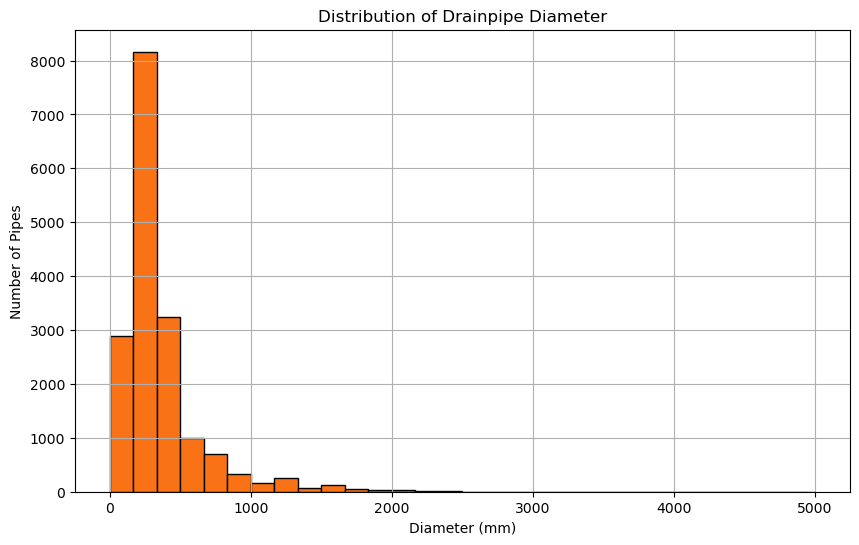

In [12]:
plt.figure(figsize = (10, 6))
plt.hist(drainpipes_clean['diameter'].dropna(), bins = 30, edgecolor = 'black', color = '#F97316')
plt.title('Distribution of Drainpipe Diameter')
plt.xlabel('Diameter (mm)')
plt.ylabel('Number of Pipes')
plt.grid(True)
plt.show()

<div id="subsection-5-2" class="usecase-sub-section-heading"><b>5.2. Distribution of infrastructure condition</b></div>

<div class="usecase-body">The dataset includes a numeric <code>condition</code> rating for each pipe. Higher values are treated here as indicating worse condition, consistent with common council asset-condition scales — this assumption is stated explicitly because the dataset's own documentation does not define the scale, and it should be confirmed against the City of Melbourne's asset management documentation before this use case is relied on for real prioritisation decisions.</div>

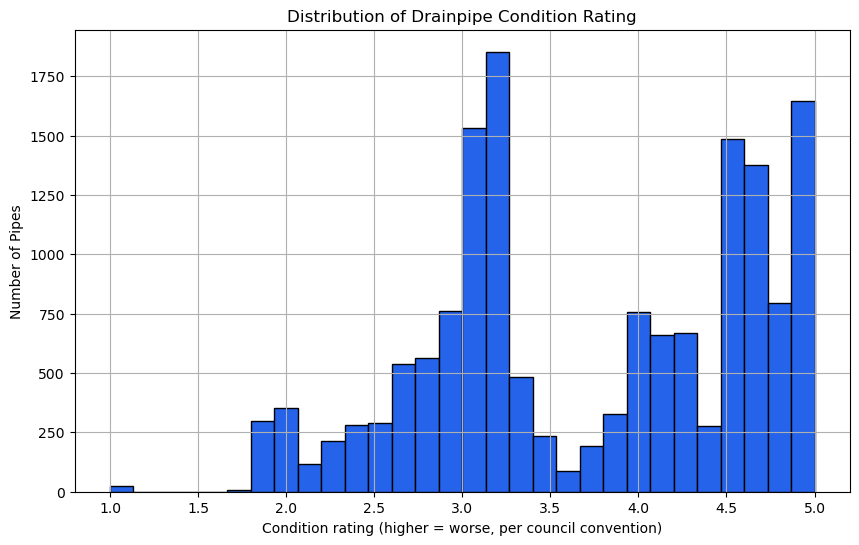

In [13]:
plt.figure(figsize = (10, 6))
plt.hist(drainpipes_clean['condition'].dropna(), bins = 30, edgecolor = 'black', color = '#2563EB')
plt.title('Distribution of Drainpipe Condition Rating')
plt.xlabel('Condition rating (higher = worse, per council convention)')
plt.ylabel('Number of Pipes')
plt.grid(True)
plt.show()

<div id="subsection-5-3" class="usecase-sub-section-heading"><b>5.3. Assigning capacity and condition risk bands</b></div>

<div class="usecase-body">Both signals are converted into a 1–4 risk band using quartiles rather than fixed cut-offs, so that a band of 4 always means "in the worst quarter of the network," regardless of how the raw values are distributed:</div>

<div class="usecase-list">

- **Capacity risk** — the narrowest quarter of pipes by diameter are banded as the highest risk, since they carry the least water before overflowing.
- **Condition risk** — the worst-rated quarter of pipes by condition are banded as the highest risk.

</div>

In [14]:
# Capacity risk: narrower pipes = higher risk, so the rank is inverted before banding
drainpipes_clean['capacity_risk'] = np.ceil(
    (1 - drainpipes_clean['diameter'].rank(pct = True)) * 4
).clip(1, 4)

# Condition risk: higher recorded condition value = higher risk
drainpipes_clean['condition_risk'] = np.ceil(
    drainpipes_clean['condition'].rank(pct = True) * 4
).clip(1, 4)

drainpipes_clean[['diameter', 'capacity_risk', 'condition', 'condition_risk']].head(10)

,diameter,capacity_risk,condition,condition_risk
0,150.0,4.0,3.000000,1.0
1,150.0,4.0,3.000000,1.0
2,150.0,4.0,3.000000,1.0
3,150.0,4.0,4.921821,4.0
4,1200.0,1.0,2.542013,1.0
5,300.0,3.0,2.703226,1.0
6,300.0,3.0,3.203208,2.0
7,300.0,3.0,4.753806,4.0
8,600.0,1.0,NaN,NaN
9,300.0,3.0,4.541994,3.0


<div id="section-6" class="usecase-section-heading"><b>6. Assessing drainage network density</b></div>

<div class="usecase-body">A pipe can be in excellent condition and still be part of a network that is too sparse for the area it serves. This section adds a third, independent signal based purely on how many stormwater assets exist in a given part of the city.</div>

<div id="subsection-6-1" class="usecase-sub-section-heading"><b>6.1. Binning infrastructure into location grids</b></div>

<div class="usecase-body">Both datasets are grouped into ~100 metre grid squares (roughly a city block) by rounding latitude and longitude to 3 decimal places. This grid size is deliberately coarse rather than very fine, so that squares are large enough for stormwater pits and drainpipes to genuinely overlap in the same square — a lesson learned from an earlier use case, where an overly fine grid meant almost every square only ever contained one dataset.</div>

In [15]:
def assign_location_bins(df, lat_col, lon_col, precision = 3):
    df = df.copy()
    df['lat_bin'] = df[lat_col].round(precision)
    df['lon_bin'] = df[lon_col].round(precision)
    return df

pits_binned = assign_location_bins(stormwater_pits_clean, 'lat', 'lon')
pipes_binned = assign_location_bins(drainpipes_clean, 'latitude', 'longitude')

<div id="subsection-6-2" class="usecase-sub-section-heading"><b>6.2. Calculating a density risk band</b></div>

<div class="usecase-body">For each grid square, the number of stormwater pits and drainpipes is counted and combined into a single asset count. That count is then converted into a risk band using the same quartile approach as before, but inverted: grid squares with the <i>fewest</i> assets are the ones treated as highest risk, since they have the least drainage infrastructure serving that part of the city.</div>

In [16]:
pit_counts = pits_binned.groupby(['lat_bin', 'lon_bin']).size().reset_index(name = 'pit_count')
pipe_counts = pipes_binned.groupby(['lat_bin', 'lon_bin']).size().reset_index(name = 'pipe_count')

density = pd.merge(pit_counts, pipe_counts, on = ['lat_bin', 'lon_bin'], how = 'outer').fillna(0)
density['asset_count'] = density['pit_count'] + density['pipe_count']

# Fewer assets = higher risk, so the rank is inverted before banding
density['density_risk'] = np.ceil(
    (1 - density['asset_count'].rank(pct = True)) * 4
).clip(1, 4)

density = density[['lat_bin', 'lon_bin', 'density_risk']]
density.head(10)

,lat_bin,lon_bin,density_risk
0,-37.850,144.980,4.0
1,-37.850,144.981,2.0
2,-37.849,144.980,4.0
3,-37.849,144.981,4.0
4,-37.848,144.980,2.0
5,-37.848,144.981,3.0
6,-37.848,144.982,2.0
7,-37.848,144.983,3.0
8,-37.848,144.984,3.0
9,-37.848,144.985,4.0


<div id="section-7" class="usecase-section-heading"><b>7. Calculating the flood risk score</b></div>

<div class="usecase-body">With capacity, condition and density each expressed as a comparable 1–4 band, they can now be combined into a single flood risk score per grid square.</div>

<div id="subsection-7-1" class="usecase-sub-section-heading"><b>7.1. Combine the risk signals</b></div>

<div class="usecase-body">Capacity and condition risk are calculated per pipe, so they are first aggregated to one value per grid square before merging with the density score.</div>

<div class="usecase-body">The final score averages only across the signals that actually have data for a given square, rather than filling missing signals in with 0 first. Filling gaps with 0 would treat "no drainpipe recorded in this square" as "this square scored zero for drainage," which would drag the score down for reasons that reflect data coverage rather than genuine flood risk — the same mistake identified and corrected in an earlier use case in this series. A <code>sources_count</code> column is kept alongside the score as a visible confidence measure: a score built from three signals is far more trustworthy than the same score built from one.</div>

In [17]:
pipe_risk_by_bin = pipes_binned.groupby(['lat_bin', 'lon_bin'], as_index = False)[
    ['capacity_risk', 'condition_risk']
].mean()

dfs = [pipe_risk_by_bin, density]
combined_df = reduce(lambda left, right: pd.merge(left, right, on = ['lat_bin', 'lon_bin'], how = 'outer'), dfs)

risk_cols = ['capacity_risk', 'condition_risk', 'density_risk']
combined_df['sources_count'] = combined_df[risk_cols].notna().sum(axis = 1)
combined_df['flood_risk_score'] = combined_df[risk_cols].mean(axis = 1, skipna = True)

print("Grid squares by number of contributing risk signals:")
print(combined_df['sources_count'].value_counts().sort_index())

combined_df.describe()[['flood_risk_score']]

Grid squares by number of contributing risk signals:
sources_count
1     277
2     142
3    1980
Name: count, dtype: int64


,flood_risk_score
count,2399.000000
mean,2.644716
std,0.695258
min,1.176471
25%,2.127940
50%,2.533333
75%,3.000000
max,4.000000


<div id="subsection-7-2" class="usecase-sub-section-heading"><b>7.2. Distribution of the flood risk score</b></div>

<div class="usecase-body">The histogram below shows how the final flood risk score is distributed across the city, giving a first sense of whether risk is concentrated in a small number of areas or spread broadly.</div>

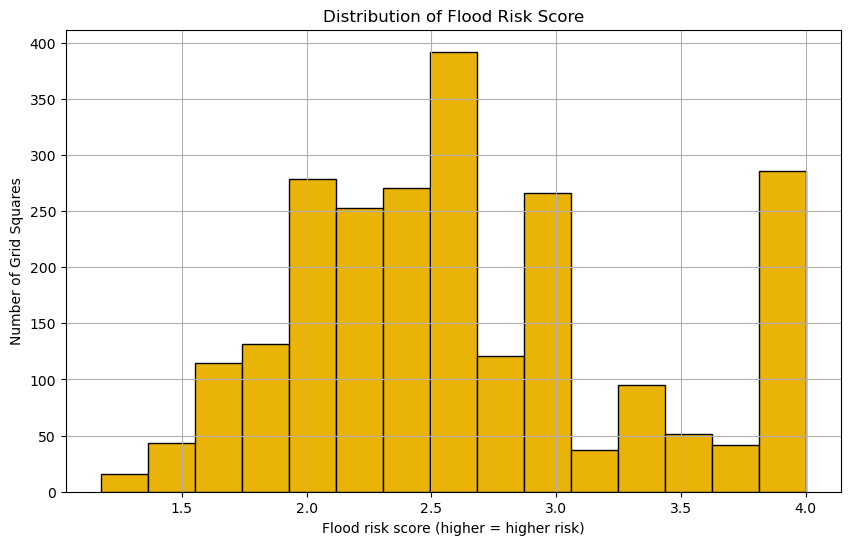

In [18]:
plt.figure(figsize = (10, 6))
plt.hist(combined_df['flood_risk_score'], bins = 15, edgecolor = 'black', color = '#EAB308')
plt.title('Distribution of Flood Risk Score')
plt.xlabel('Flood risk score (higher = higher risk)')
plt.ylabel('Number of Grid Squares')
plt.grid(True)
plt.show()

<div id="section-8" class="usecase-section-heading"><b>8. Mapping high-risk flood zones</b></div>

<div class="usecase-body">This final section brings the analysis together to directly answer the scenario's questions: where the weakest drainage is, and which locations should be prioritised first.</div>

<div id="subsection-8-1" class="usecase-sub-section-heading"><b>8.1. Heatmap of flood risk across the city</b></div>

<div class="usecase-body">An interactive heatmap is used to visualise the flood risk score across every grid square. The gradient runs from green (low risk) to red (high risk), and the legend below is built from the exact same colour stops passed to the heatmap, so the two always match.</div>

In [19]:
m = folium.Map(location = [-37.8136, 144.9631], zoom_start = 13, tiles = 'CartoDB positron')

# The score is on a 1-4 scale (from the quartile banding used to build it), but HeatMap's gradient
# stops are defined on a 0-1 scale. Passing the raw 1-4 score in means almost every point would exceed
# the highest gradient stop and render in the single worst colour, hiding all real variation.
# Normalising against the theoretical 1-4 range (rather than the observed min/max) keeps the colour
# meaningful as "how close to the worst possible score", not just relative to this particular run's data.
combined_df['normalised_risk'] = ((combined_df['flood_risk_score'] - 1) / (4 - 1)).clip(0, 1)

heat_data = [
    [row['lat_bin'], row['lon_bin'], row['normalised_risk']]
    for _, row in combined_df.iterrows()
]

risk_gradient = {
    "0.0": "#059669",
    "0.35": "#EAB308",
    "0.65": "#F97316",
    "1.0": "#B91C1C"
}

HeatMap(heat_data, radius = 18, gradient = risk_gradient).add_to(m)

score_min = combined_df['flood_risk_score'].min()
score_max = combined_df['flood_risk_score'].max()

legend_html = f"""
<div style="position: fixed;
            bottom: 40px; left: 40px; width: 260px;
            background-color: rgba(255, 255, 255, 0.9); border:2px solid grey; z-index:1000; font-size:14px;
            padding: 12px;">
<b>Flood Risk Score</b><br><br>
<div style="width:100%; height:16px; border-radius:3px;
            background: linear-gradient(to right, #059669, #EAB308, #F97316, #B91C1C);">
</div>
<div style="display:flex; justify-content:space-between; margin-top:4px;">
    <span>Low ({score_min:.2f})</span>
    <span>High ({score_max:.2f})</span>
</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m

<div id="subsection-8-2" class="usecase-sub-section-heading"><b>8.2. Identifying the highest-risk locations</b></div>

<div class="usecase-body">Ranking purely on the highest score turns out to be misleading here. The very top of that list is dominated by grid squares scored from a single signal — squares that contain stormwater pits but no recorded drainpipes at all, so their score comes entirely from the density measure with no capacity or condition evidence behind it. Those squares are worth knowing about, but they answer a different question from "where is the drainage weakest".</div>

<div class="usecase-body">The two cases are therefore reported separately below: first the highest-risk locations that are backed by all three signals, which is the list an engineer could act on with reasonable confidence; then the squares with no drainpipe record at all, which are flagged as a data gap worth verifying rather than a confirmed risk.</div>

In [20]:
# Highest-risk locations backed by all three signals - the actionable list
high_confidence = combined_df[combined_df['sources_count'] == 3]

top_risk = high_confidence.sort_values('flood_risk_score', ascending = False).head(10)

print(f"Highest-risk locations backed by all three signals "
      f"({len(high_confidence)} of {len(combined_df)} grid squares qualify):")
display(top_risk[['lat_bin', 'lon_bin', 'capacity_risk', 'condition_risk',
                  'density_risk', 'flood_risk_score']])

# Squares with no drainpipe record at all - a data gap rather than a confirmed risk
no_pipe_data = combined_df[combined_df['capacity_risk'].isna()]

print(f"\nGrid squares containing stormwater pits but no recorded drainpipes: {len(no_pipe_data)}")
print("These are flagged as a data gap to verify, not as confirmed high-risk areas.")
display(no_pipe_data[['lat_bin', 'lon_bin', 'density_risk', 'flood_risk_score']].head(10))

Highest-risk locations backed by all three signals (1980 of 2399 grid squares qualify):


,lat_bin,lon_bin,capacity_risk,condition_risk,density_risk,flood_risk_score
847,-37.816,144.940,4.0,4.0,4.0,4.0
1110,-37.812,144.982,4.0,4.0,4.0,4.0
1224,-37.810,144.974,4.0,4.0,4.0,4.0
1997,-37.794,144.952,4.0,4.0,4.0,4.0
173,-37.832,144.975,4.0,4.0,4.0,4.0
607,-37.822,144.976,4.0,4.0,4.0,4.0
2274,-37.783,144.917,4.0,4.0,4.0,4.0
733,-37.819,144.942,4.0,4.0,4.0,4.0
1956,-37.795,144.953,4.0,4.0,4.0,4.0
2261,-37.784,144.918,4.0,4.0,4.0,4.0



Grid squares containing stormwater pits but no recorded drainpipes: 277
These are flagged as a data gap to verify, not as confirmed high-risk areas.


,lat_bin,lon_bin,density_risk,flood_risk_score
0,-37.850,144.980,4.0,4.0
9,-37.848,144.985,4.0,4.0
13,-37.846,144.980,4.0,4.0
28,-37.844,144.982,4.0,4.0
55,-37.840,144.901,4.0,4.0
57,-37.840,144.914,4.0,4.0
58,-37.840,144.915,4.0,4.0
65,-37.839,144.902,4.0,4.0
67,-37.839,144.906,4.0,4.0
72,-37.839,144.976,4.0,4.0


<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">This use case combined two City of Melbourne stormwater datasets to build a theoretical flood risk score for different parts of the city, based on drainage capacity, infrastructure condition and network density.</div>

<div class="usecase-body"><b>What we achieved in this analysis</b></div>

<div class="usecase-body">Two datasets covering over 38,000 stormwater assets were retrieved, cleaned and combined into a single risk score per grid square across the city. Three independent signals — pipe capacity, pipe condition and network density — were each converted into a comparable risk band and combined without fabricating data for the squares that any individual dataset did not cover.</div>

<div class="usecase-body">This directly answers the two questions posed in the Scenario. Which parts of the city have the weakest drainage is answered by the flood risk heatmap and, more precisely, by the ranked list of highest-risk locations in Section 8.2 that are backed by all three signals. Where infrastructure upgrades and emergency response planning should be prioritised first is answered by that same high-confidence list — those are the specific locations this analysis suggests investigating before the squares flagged only as data gaps.</div>

<div class="usecase-body"><b>What we learned from this analysis</b></div>

<div class="usecase-body">No single dataset was enough on its own to describe flood risk. Pipe capacity alone ignores condition, condition alone ignores coverage, and none of them measures actual water flow. Combining several independent, imperfect signals produced a far more defensible picture than any one of them could alone, provided the combination is done carefully — averaging only across the signals that actually have data for a location, rather than treating missing data as a real zero score, made a meaningful difference to how trustworthy the final result is.</div>

<div class="usecase-body">Tracking how many signals backed each score also turned out to matter more than expected. Ranking locations purely by score put the squares with the <i>least</i> evidence at the very top, because a square containing pits but no recorded drainpipes scores highly on density alone with nothing to balance it. Separating high-confidence results from data gaps was necessary to stop the analysis presenting missing data as though it were a confirmed finding.</div>

<div class="usecase-body"><b>Observations for further opportunities</b></div>

<div class="usecase-body">The clearest next step is verifying the direction of the <code>condition</code> rating against the City of Melbourne's own asset management documentation, since this analysis currently assumes higher values mean worse condition. Beyond that, this theoretical score could be meaningfully strengthened by incorporating actual rainfall and topographic elevation data to move from a proxy for drainage weakness towards a genuine water-flow simulation, and by resolving the 3D mesh dataset through a proper 3D data access method rather than the tabular export used here.</div>